In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

import re
import glob

##### funciones auxiliares

In [2]:
def convergencia(tiempo, fotones, tol=1e-3, porcentaje=0.1):
    npoints = int(len(tiempo) * porcentaje)
    if npoints < 2:
        return False, np.nan # no hay suficientes puntos
    fotones = fotones[-npoints:]
    tiempo = tiempo[-npoints:]
    df = np.gradient(fotones, tiempo)
    df_mean = np.mean(np.abs(df))
    return df_mean < tol, df_mean

In [3]:
def procesafile(at, lvl, folder):
    global omegas, Nss, non_converged, Probs, niveles, title, label
    omegas = []
    Probs = [[] for _ in np.arange(lvl**at)]
    Nss = []
    label = f"{at}at{lvl}lvl"
    path = os.path.join(label, folder)
    
    non_converged = []
    files = glob.glob(os.path.join(label,'*.h5'))
    for file in files:
        title = ""
        with h5py.File(file, 'r') as f:
            dataset = os.path.basename(file).replace('.h5', '')
            
            g = f[dataset].attrs['g']
            Omega_DR = f[dataset].attrs['Omega_DR']
            gamma_12 = f[dataset].attrs['gamma_12']
            gamma_s = f[dataset].attrs['gamma_s']
            gamma_e = f[dataset].attrs['gamma_e']
            title += f'Omega_DR = {Omega_DR} \n gamma_12 = {gamma_12} \n gamma_s = {gamma_s} \n gamma_e = {gamma_e} \n'

            kappa = f[dataset].attrs['kappa']
            rabi_b = f[dataset].attrs['rabi_b']
            rabi_c = f[dataset].attrs['rabi_c']
            omega = f[dataset].attrs['Omega_EE']
            tt = f[dataset].attrs['t']
            niveles = f[dataset].attrs['probs_label']
            tiempo = np.linspace(float(tt[0]), float(tt[1]), int(tt[2]))
            title = f'g={g} \n {title} kappa={kappa} \n rabi_b={rabi_b} \n rabi_c={rabi_c}'
    
            if dataset not in f:
                print(f"  no se encontró el dataset '{dataset}' en el archivo. Saltando.")
                continue

            omegas.append(omega)
            rho = f[dataset][:]
            lvl_prob = [rho[:, i] for i in np.arange(lvl**at)] # las primeras n columnas son las probabilidades
            N_expect = rho[:, lvl**at] # la última columna es el valor medio de fotones en la cavidad

            # promediamos el último 25% de los puntos
            npoints = int(rho.shape[0] * 0.25)
            Nss.append(np.mean(N_expect[-npoints:]))
            for i,ele in enumerate(lvl_prob):
                Probs[i].append(np.mean(ele[-npoints:]))
            
            is_converged, derivative = convergencia(tiempo, N_expect)
            if not is_converged:
                non_converged.append([omega, np.mean(N_expect[-npoints:])])
                
    # ordena por omega para mejorar la gráfica
    omegas = np.array(omegas)
    sorti = np.argsort(omegas)
    
    omegas = omegas[sorti]
    Nss = np.array(Nss)[sorti]
    Probs = [np.array(p)[sorti] for p in Probs]

In [9]:
def p_fotones():
    plt.plot(omegas, Nss, 'o-', zorder=5, label=label)
    if non_converged:
        dtn = [ele[0] for ele in non_converged]
        nmean = [ele[1] for ele in non_converged]
        plt.scatter(dtn, nmean, color="red")
    plt.title(title)
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel(f"omega")
    plt.ylabel("fotones promedio <N>")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    return plt
def p_probs(plvls):
    for plvl in plvls:
        if len(plvl) == 1:
            indices = [i for i, label in enumerate(niveles) if (plvl in label) and (label.count(plvl) == 1)]
        else:
            indices = [i for i,label in enumerate(niveles) if plvl in label]
        prob = np.sum([Probs[i] for i in indices], axis=0)
        plt.plot(omegas, prob, 'o-', label=f'P({plvl})', markersize=5)
    plt.title(title)
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel(f"omega")
    plt.ylabel("probabilidad de ocupación")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    return plt

##### 2 átomos 4 niveles

In [10]:
procesafile(2, 4, "")

<module 'matplotlib.pyplot' from '/home/ultrxvioletx/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

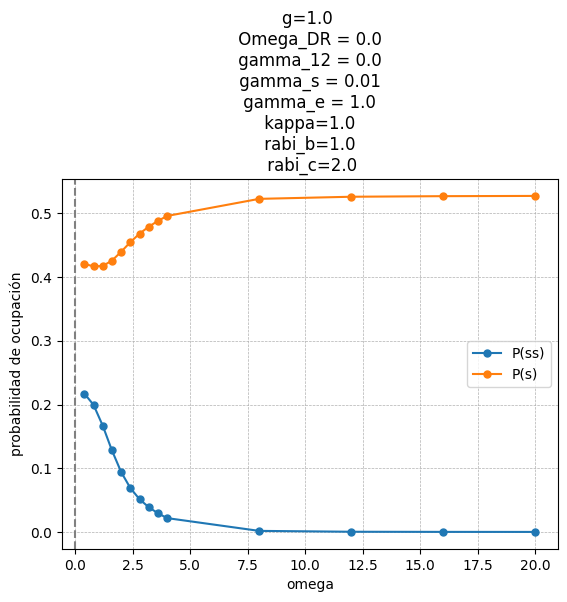

In [11]:
p_probs(["ss","s"])